# 02_01 — PacBio cell counts per tissue, colored by donor

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# use Arial for all text
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
sc.settings.verbosity = 1

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# Load the all-samples recollapsed genes object (obs carries donor / tissue / tube_id,
# joined from csvs/sample_metadata.csv in notebook 01_01).
adata = sc.read_h5ad(
    "./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad"
)
print(adata.shape)
adata.obs[["tube_id", "donor", "tissue"]].head()

(203311, 854410)


,tube_id,donor,tissue
CGCAACTCTAGTCTCA-1_T66,T66,TSP10,Blood
GACCAGCTGTGGGACA-1_T66,T66,TSP10,Blood
GGGTGTCTGACATCGT-1_T66,T66,TSP10,Blood
TAGGCCGACAGCTTGT-1_T66,T66,TSP10,Blood
TGCCGGATGTCATTTC-1_T66,T66,TSP10,Blood


In [3]:
# Cell counts per tissue (tube_id), keeping its donor + tissue name.
counts = (
    adata.obs.groupby(["donor", "tube_id", "tissue"], observed=True)
    .size()
    .reset_index(name="n_cells")
)

# Order bars by donor, then by descending cell count within each donor.
counts = counts.sort_values(["donor", "n_cells"], ascending=[True, False]).reset_index(drop=True)

# Readable x-axis label: tissue name + tube_id.
counts["label"] = counts["tissue"].astype(str) + " (" + counts["tube_id"].astype(str) + ")"

print(f"{counts.shape[0]} tissues across {counts['donor'].nunique()} donors; "
      f"{counts['n_cells'].sum():,} cells total")
counts

60 tissues across 12 donors; 203,311 cells total


,donor,tube_id,tissue,n_cells,label
0,TSP2,T59,Lung,4957,Lung (T59)
1,TSP2,T75,Kidney,2114,Kidney (T75)
2,TSP4,T61,Uterus,4065,Uterus (T61)
3,TSP7,T62,Blood,7282,Blood (T62)
4,TSP9,T68,Pancreas,3249,Pancreas (T68)
5,TSP10,T66,Blood,3504,Blood (T66)
6,TSP19,T60,Liver,3814,Liver (T60)
7,TSP21,T53,Fat,3985,Fat (T53)
8,TSP21,T31,Uterus,3789,Uterus (T31)
9,TSP21,T64,Vasculature,3457,Vasculature (T64)


In [4]:
import re

# --- donor -> sex from csvs/DonorData.txt -----------------------------------
# DonorData.txt is tab-separated; rows are "Donor NN" with a Sex column (M/F).
# Our donor ids are TSP<n>, which map to "Donor {n:01_10}".
# (Defined here — before the bar/bubble plots — so both can split by sex.)
donor_sex = {}
with open("./../csvs/DonorData.txt") as fh:
    header = fh.readline().rstrip("\n").split("\t")
    si = header.index("Sex")
    for line in fh:
        parts = line.rstrip("\n").split("\t")
        m = re.match(r"Donor\s+0*(\d+)", parts[0])
        if not m:
            continue
        sex = parts[si].strip().upper()
        if sex in ("M", "F"):
            donor_sex[f"TSP{int(m.group(1))}"] = "Male" if sex == "M" else "Female"

# DonorData.txt only covers Donor 01-30, so TSP32/TSP33 are missing. Fill those
# from the short-read metadata (which agrees with DonorData.txt on every
# overlapping donor).
sr_meta = pd.read_csv("./../csvs/all_donors_shortread_LR_matched_anndata_metadata.csv")
for dt, sx in zip(sr_meta["donor_tissue"].astype(str), sr_meta["sex"].astype(str)):
    mm = re.match(r"(TSP\d+)_", dt)
    if mm and mm.group(1) not in donor_sex and sx.lower() in ("male", "female"):
        donor_sex[mm.group(1)] = sx.capitalize()

missing = sorted(set(counts["donor"]) - set(donor_sex))
print({d: donor_sex.get(d) for d in sorted(counts["donor"].unique(), key=lambda x: int(x[3:]))})
if missing:
    print("WARNING: no sex found for:", missing)

/tmp/ipykernel_27365/3420715774.py:23: DtypeWarning: Columns (24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  sr_meta = pd.read_csv("./../csvs/all_donors_shortread_LR_matched_anndata_metadata.csv")


{'TSP2': 'Female', 'TSP4': 'Female', 'TSP7': 'Female', 'TSP9': 'Male', 'TSP10': 'Male', 'TSP19': 'Female', 'TSP21': 'Female', 'TSP25': 'Male', 'TSP27': 'Female', 'TSP28': 'Female', 'TSP32': 'Male', 'TSP33': 'Male'}


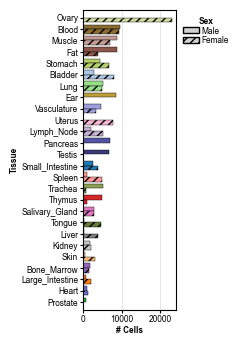

In [5]:
# Merged horizontal bar plot: tissues on the y-axis, cell count on the x-axis.
# Male and female bars are shown for every tissue (grouped), colored by tissue.
# tube_ids removed: cells summed over all tubes/donors of a given (tissue, sex).
import random
from matplotlib.patches import Patch

# --- formatting ------------
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 2.0
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6, "legend.labelspacing" : 0.1,
    "legend.borderpad" : 0.3,
    "legend.handletextpad" : 0.2,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6, "figure.titlesize": 6,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# total cells per (tissue, sex) — tube_ids and donors collapsed
bar = counts.groupby(["donor", "tissue"], observed=True)["n_cells"].sum().reset_index()
bar["sex"] = bar["donor"].map(donor_sex)
pivot = (
    bar.groupby(["tissue", "sex"], observed=True)["n_cells"].sum()
    .unstack("sex").reindex(columns=["Male", "Female"]).fillna(0.0)
)

# tissue order: total cells desc, largest at top
tissue_tot = pivot.sum(axis=1).sort_values(ascending=False)
y_order = list(reversed(tissue_tot.index))
pivot = pivot.reindex(y_order)

# color by tissue: same 26-color shuffled palette as the bubble plot
palette40 = sns.color_palette("tab20", 16) + sns.color_palette("tab20b", 10)
random.Random(1).shuffle(palette40)
tissue_palette = dict(zip(list(tissue_tot.index), palette40[:len(tissue_tot)]))
colors = [tissue_palette[t] for t in y_order]

# grouped horizontal bars: Male above, Female below, at each tissue row
y = np.arange(len(y_order))
h = 0.4
fig, ax = plt.subplots(figsize=(1.2, 0.15 * len(y_order)))
ax.barh(y + h / 2, pivot["Male"].values, height=h, color=colors,
        edgecolor="black", linewidth=0.3)
ax.barh(y - h / 2, pivot["Female"].values, height=h, color=colors,
        edgecolor="black", linewidth=0.3, hatch="////")

ax.set_yticks(y)
ax.set_yticklabels(y_order)
ax.set_ylim(-0.7, len(y_order) - 0.3)
ax.set_xlabel("# Cells")
ax.set_ylabel("Tissue")
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
ax.grid(axis="x", alpha=0.3)

# legend maps hatch -> sex (color already encodes tissue)
sex_handles = [
    Patch(facecolor="lightgrey", edgecolor="black", label="Male"),
    Patch(facecolor="lightgrey", edgecolor="black", hatch="////", label="Female"),
]
leg = ax.legend(handles=sex_handles, title="Sex", frameon=False,
                bbox_to_anchor=(1.0, 1.0), loc="upper left")
leg.get_title().set_fontweight("bold")

plt.savefig(figpath("02_01_pacbio_cell_counts_bar_bysex.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [6]:
# Per-donor totals for reference.
donor_totals = (
    counts.groupby("donor")["n_cells"].sum().sort_values(ascending=False).reset_index()
)
donor_totals

/tmp/ipykernel_27365/2775411090.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts.groupby("donor")["n_cells"].sum().sort_values(ascending=False).reset_index()


,donor,n_cells
0,TSP33,62087
1,TSP27,50618
2,TSP21,21211
3,TSP25,21201
4,TSP28,17420
5,TSP7,7282
6,TSP2,7071
7,TSP4,4065
8,TSP19,3814
9,TSP10,3504


## Bubble plot with marginal bar plots, split by donor sex

Two panels — **Male** donors (left) and **Female** donors (right) — sharing a common tissue y-axis. Donors on the x-axis, tissue name (no tube_id) on the y-axis, bubble size = number of cells; **dots are colored by tissue**. Tubes of the same tissue within a donor are summed so a shared tissue lines up on one row. Top bars = total cells per donor; right bars = total cells per tissue summed across all donors. Donor sex comes from `csvs/DonorData.txt` (TSP32/TSP33 filled from the short-read metadata, which it omits).

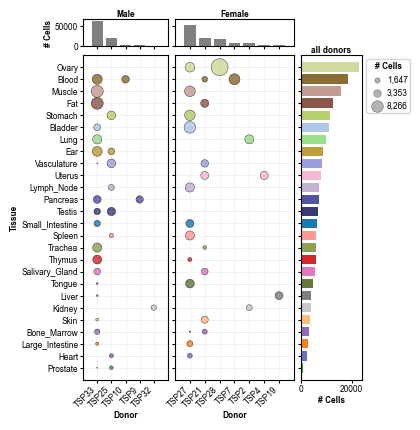

In [7]:
import random

# --- tunable spacing (points) -----------------------------------------------
TICK_LEN = 2.0         # length of tick marks
TICK_LABEL_PAD = 1.5   # gap between tick marks and their tick labels
AXIS_LABEL_PAD = 1.5   # gap between the axis and its axis label
PANEL_TITLE_PAD = 2.0  # gap between the Male/Female bar-plot titles and their axes

# fonts: everything at 6 pt (incl. legend titles); axis/figure titles bold
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    # spacing driven by the variables above
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# --- aggregate to tissue level ----------------------------------------------
# Sum tubes of the same tissue within a donor so shared tissues share one row.
bub = (
    counts.groupby(["donor", "tissue"], observed=True)["n_cells"]
    .sum()
    .reset_index()
)
bub["sex"] = bub["donor"].map(donor_sex)

# --- shared tissue y-axis order (by total cells across all donors) ----------
tissue_tot = bub.groupby("tissue", observed=True)["n_cells"].sum().sort_values(ascending=False)
y_labels = list(reversed(tissue_tot.index))    # bottom -> top, largest at top
tissue_pos = {t: i for i, t in enumerate(y_labels)}

# per-donor totals (for the top marginal)
donor_tot = bub.groupby("donor", observed=True)["n_cells"].sum()

# color the dots by tissue: 40-color pool (tab20 + tab20b), shuffled, take 26
tissues_sorted = list(tissue_tot.index)
palette40 = sns.color_palette("tab20", 16) + sns.color_palette("tab20b", 10)
random.Random(1).shuffle(palette40)
tissue_palette = dict(zip(tissues_sorted, palette40[:len(tissues_sorted)]))

# bubble-size scaling (marker area in pts^2), shared across both panels
max_cells = bub["n_cells"].max()
size_scale = 150.0 / max_cells

# extra data-margin so the largest bubble (Ovary) isn't clipped by the axes box
PAD = 1.0

# donors split by sex, each ordered by total cells desc
sexes = ["Male", "Female"]
sex_donors = {
    s: list(donor_tot.loc[[d for d in donor_tot.index if donor_sex.get(d) == s]]
            .sort_values(ascending=False).index)
    for s in sexes
}
n_male, n_female = len(sex_donors["Male"]), len(sex_donors["Female"])

# --- figure: [Male main | Female main | per-tissue marginal] ----------------
fig = plt.figure(figsize=(0.3 * (n_male + n_female), 0.18 * len(y_labels)))
gs = fig.add_gridspec(
    2, 3, width_ratios=[n_male, n_female, max(2, 0.3 * (n_male + n_female))],
    height_ratios=[0.5, 6], wspace=0.08, hspace=0.05,
)
ax_m = fig.add_subplot(gs[1, 0])
ax_f = fig.add_subplot(gs[1, 1], sharey=ax_m)
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_m)
ax_top_m = fig.add_subplot(gs[0, 0], sharex=ax_m)
# the two top bar charts share a y-axis so they use one common scale + labels
ax_top_f = fig.add_subplot(gs[0, 1], sharex=ax_f, sharey=ax_top_m)


def draw_panel(ax, ax_top, sex):
    ds = sex_donors[sex]
    dpos = {d: i for i, d in enumerate(ds)}
    sub = bub[bub["donor"].isin(ds)]
    ax.scatter(
        [dpos[d] for d in sub["donor"]],
        [tissue_pos[t] for t in sub["tissue"]],
        s=sub["n_cells"] * size_scale,
        c=[tissue_palette[t] for t in sub["tissue"]],
        alpha=0.85, edgecolor="black", linewidth=0.3,
    )
    ax.set_xticks(range(len(ds)))
    ax.set_xticklabels(ds, rotation=45, ha="right")
    ax.set_xlim(-PAD, len(ds) - 1 + PAD)
    ax.set_ylim(-PAD, len(y_labels) - 1 + PAD)
    ax.set_xlabel("Donor")
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    # top marginal: total cells per donor
    ax_top.bar(range(len(ds)), donor_tot.reindex(ds).values, color="grey")
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_top.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    ax_top.set_title(sex, pad=PANEL_TITLE_PAD)


draw_panel(ax_m, ax_top_m, "Male")
draw_panel(ax_f, ax_top_f, "Female")

# shared top-bar y-axis: label on the left one, hide the right one's tick labels
ax_top_m.set_ylabel("# Cells")
plt.setp(ax_top_f.get_yticklabels(), visible=False)

# y-axis (tissues) only on the leftmost main panel
ax_m.set_yticks(range(len(y_labels)))
ax_m.set_yticklabels(y_labels)
ax_m.set_ylabel("Tissue")
plt.setp(ax_f.get_yticklabels(), visible=False)

# right marginal: total cells per tissue across all donors, same tissue palette
ax_right.barh(range(len(y_labels)), tissue_tot.reindex(y_labels).values,
              color=[tissue_palette[t] for t in y_labels])
ax_right.set_title("all donors", pad=PANEL_TITLE_PAD)
ax_right.set_xlabel("# Cells")
# keep the x tick labels (counts); tissue y-axis is shared with the main panel
ax_right.tick_params(axis="y", labelleft=False)
ax_right.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)

# bubble-size legend (on the right marginal)
legend_vals = [int(v) for v in np.quantile(bub["n_cells"], [0.25, 0.5, 0.95])]
legend_vals = sorted(set(v for v in legend_vals if v > 0))
for v in legend_vals:
    ax_right.scatter([], [], s=v * size_scale, c="grey", alpha=0.6,
                     edgecolor="black", linewidth=0.3, label=f"{v:,}")
leg = ax_right.legend(title="# Cells", labelspacing=0.5, borderpad=0.3, handletextpad = 0.2,
                      bbox_to_anchor=(1., 1), loc="upper left", frameon=True)
leg.get_title().set_fontweight("bold")

# fig.suptitle("PacBio cell counts per tissue × donor, split by donor sex", y=0.95)
plt.savefig(figpath("02_01_pacbio_cell_counts_bubble_bysex.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()

## SR ↔ PacBio barcode overlap per tissue

How many cell barcodes are shared between the **PacBio** and matched **short-read (SR)** datasets, per tissue, split by donor sex. Each PacBio tube is matched to its SR sample (`csvs/sample_metadata.csv` → `SR_sample_id`) and barcodes are compared at the 10x-run level with the cross-platform key `SR_sample_id + "___" + 10X_barcode` (barcodes are only unique within a run). PacBio barcodes are reverse-complemented back to the forward strand before matching (the whitelist is RC'd); the SR side already stores the forward-strand key (`sample_id_10X_barcode`). SR barcodes come from the LR-matched 3′ short-read object metadata (`csvs/all_donors_shortread_LR_matched_anndata_metadata.csv`). Overlap is computed per tube (= per SR sample), then **summed to (tissue, sex)** over all tubes and donors.

**Left panel** — grouped horizontal bars like the cell-count bar plot: **Male above / Female below** per tissue row (Female hatched, donor sex from `csvs/DonorData.txt` + short-read metadata for TSP32/33), each stacked **shared (SR ∩ PacBio)** + **PacBio-only**. **Right panel** — overlap fraction in both directions (shared / PacBio and shared / SR), with the Male/Female markers offset to line up with the bars; shared / SR is small because SR captures far more cells per sample. Tubes with no SR counterpart (`No match found`) are excluded.

In [8]:
# ---------------------------------------------------------------------------
# SR <-> PacBio 10x barcode overlap, aggregated per tissue (and split by sex)
# ---------------------------------------------------------------------------
# Match key = SR_sample_id + "___" + 10X_barcode. Matching is at the 10x-run level
# (barcodes are only unique within a run), so PacBio tubes are matched to their SR
# sample via csvs/sample_metadata.csv. PacBio barcodes are stored reverse-complemented
# (the whitelist is RC'd) and must be RC'd back to the forward strand before matching;
# the SR object already stores the forward-strand key in `sample_id_10X_barcode`.
# Overlap is computed per tube (= per SR sample), then summed to (tissue, sex).
def reverse_complement(seq):
    comp = {"A": "T", "T": "A", "G": "C", "C": "G", "N": "N"}
    return "".join(comp.get(b, b) for b in seq[::-1])

# tube_id -> SR_sample_id ("No match found" for tubes with no SR counterpart)
meta = pd.read_csv("./../csvs/sample_metadata.csv", dtype=str)
tube_to_sr = dict(zip(meta["tube_id"], meta["SR_sample_id"]))

# --- PacBio side: one forward-strand match key per cell ---------------------
pb = adata.obs[["tube_id", "donor", "tissue"]].copy()
bc_fwd = [reverse_complement(x.split("-1")[0]) for x in adata.obs_names.values]
pb["key"] = pb["tube_id"].map(tube_to_sr).astype(str) + "___" + np.asarray(bc_fwd)

# --- SR side: match keys per sample (LR-matched 3' object metadata) ----------
# `sample_id_10X_barcode` is already SR_sample_id + "___" + 10X_barcode.
sr = pd.read_csv(
    "./../csvs/all_donors_shortread_LR_matched_anndata_metadata.csv",
    usecols=["sample_id", "sample_id_10X_barcode"], low_memory=False,
)
sr_keys_by_sample = sr.groupby("sample_id")["sample_id_10X_barcode"].apply(set)
sr_total_by_sample = sr.groupby("sample_id")["sample_id_10X_barcode"].nunique()

# --- overlap per PacBio tube ------------------------------------------------
rows = []
for tube, sub in pb.groupby("tube_id", observed=True):
    srid = tube_to_sr.get(tube)
    pb_keys = set(sub["key"])
    sr_keys = sr_keys_by_sample.get(srid, set())
    rows.append({
        "tube_id": tube, "donor": sub["donor"].iloc[0], "tissue": sub["tissue"].iloc[0],
        "n_pacbio": len(pb_keys), "n_sr": int(sr_total_by_sample.get(srid, 0)),
        "n_shared": len(pb_keys & sr_keys),
    })
ov_tube = pd.DataFrame(rows)
n_nomatch = int((ov_tube["n_sr"] == 0).sum())
ov_tube = ov_tube[ov_tube["n_sr"] > 0].copy()   # keep tubes with an SR counterpart
ov_tube["sex"] = ov_tube["donor"].map(donor_sex)

# --- aggregate to (tissue, sex): sum shared / pacbio / sr over tubes & donors ---
ov_ts = (
    ov_tube.groupby(["tissue", "sex"], observed=True)[["n_pacbio", "n_sr", "n_shared"]]
    .sum().reset_index()
)
ov_ts["pacbio_only"] = ov_ts["n_pacbio"] - ov_ts["n_shared"]
ov_ts["frac_pb_in_sr"] = ov_ts["n_shared"] / ov_ts["n_pacbio"]   # PacBio barcodes recovered in SR
ov_ts["frac_sr_in_pb"] = ov_ts["n_shared"] / ov_ts["n_sr"]       # SR barcodes recovered in PacBio

# per-tissue totals (both sexes) for reference + bar ordering
ov_tissue = (
    ov_tube.groupby("tissue", observed=True)[["n_pacbio", "n_sr", "n_shared"]].sum()
    .assign(frac_pb_in_sr=lambda x: x["n_shared"] / x["n_pacbio"])
    .sort_values("n_pacbio", ascending=False)
)
print(f"{ov_tube['tissue'].nunique()} tissues with an SR counterpart "
      f"({n_nomatch} PacBio tubes have no SR match, excluded)")
print(f"overall: {ov_tube['n_shared'].sum():,} shared / {ov_tube['n_pacbio'].sum():,} PacBio "
      f"= {ov_tube['n_shared'].sum() / ov_tube['n_pacbio'].sum():.1%} of PacBio barcodes recovered in SR")
ov_tissue

# [verify] the draft's "the 58 libraries with a matched short-read library".
print(f"[verify] PacBio tubes {len(ov_tube) + n_nomatch} total | "
      f"{len(ov_tube)} with a matched SR library | {n_nomatch} without")


26 tissues with an SR counterpart (2 PacBio tubes have no SR match, excluded)
overall: 160,891 shared / 197,994 PacBio = 81.3% of PacBio barcodes recovered in SR
[verify] PacBio tubes 60 total | 58 with a matched SR library | 2 without


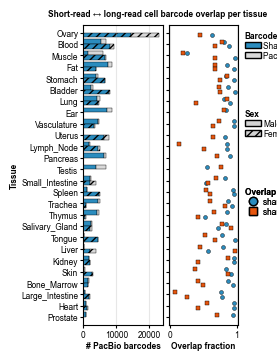

In [9]:
# --- plot: SR <-> PacBio barcode overlap per tissue, split by donor sex ------
# Left: grouped horizontal bars like the cell-count bar plot (Male above / Female below
# per tissue, Female hatched), each stacked shared (SR ∩ PacBio) + PacBio-only.
# Right: overlap fraction in both directions (shared / PacBio and shared / SR), with the
# Male/Female markers offset to line up with the bars (shared / SR is small because SR
# captures far more cells per sample).
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6, "figure.titlesize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# tissue order: total PacBio barcodes desc, largest at top
y_order = list(reversed(ov_tissue.index.tolist()))
y = np.arange(len(y_order))

def _pivot(col):
    return (ov_ts.pivot_table(index="tissue", columns="sex", values=col, observed=True)
            .reindex(index=y_order, columns=["Male", "Female"]))

shared, only, total = (_pivot(c) for c in ["n_shared", "pacbio_only", "n_pacbio"])
frac_pb, frac_sr = _pivot("frac_pb_in_sr"), _pivot("frac_sr_in_pb")

h = 0.4
SHARED_C, ONLY_C, SR_C = "#2b8cbe", "#d9d9d9", "#e6550d"

fig, (axc, axf) = plt.subplots(
    1, 2, sharey=True, figsize=(2.0, 0.15 * len(y_order)),
    gridspec_kw={"width_ratios": [1.5, 1.3], "wspace": 0.08},
)

# Panel A: stacked shared + PacBio-only, Male above / Female below (Female hatched)
for sex, off, hatch in [("Male", h / 2, None), ("Female", -h / 2, "////")]:
    sh = shared[sex].fillna(0).values
    on = only[sex].fillna(0).values
    axc.barh(y + off, sh, height=h, color=SHARED_C, edgecolor="black", linewidth=0.3, hatch=hatch)
    axc.barh(y + off, on, left=sh, height=h, color=ONLY_C, edgecolor="black", linewidth=0.3, hatch=hatch)
axc.set_yticks(y)
axc.set_yticklabels(y_order)
axc.set_ylim(-0.7, len(y_order) - 0.3)
axc.set_xlabel("# PacBio barcodes")
axc.set_ylabel("Tissue")
axc.set_xlim(0, np.nanmax(total.values) * 1.05)
axc.grid(axis="x", alpha=0.3)
axc.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)

# Panel B: overlap fraction both ways, markers offset by sex to match the bars
for sex, off in [("Male", h / 2), ("Female", -h / 2)]:
    axf.scatter(frac_pb[sex].values, y + off, s=8, c=SHARED_C, marker="o",
                edgecolor="black", linewidth=0.3, zorder=3)
    axf.scatter(frac_sr[sex].values, y + off, s=8, c=SR_C, marker="s",
                edgecolor="black", linewidth=0.3, zorder=3)
axf.set_xlim(-0.02, 1.02)
axf.set_xlabel("Overlap fraction")
axf.grid(axis="x", alpha=0.3)
axf.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)

# all legends to the right of the plots (stacked top-down on the right panel)
type_handles = [Patch(facecolor=SHARED_C, edgecolor="black", label="Shared (SR ∩ PacBio)"),
                Patch(facecolor=ONLY_C, edgecolor="black", label="PacBio only")]
sex_handles = [Patch(facecolor="lightgrey", edgecolor="black", label="Male"),
               Patch(facecolor="lightgrey", edgecolor="black", hatch="////", label="Female")]
dir_handles = [Line2D([], [], marker="o", color=SHARED_C, markeredgecolor="black",
                      linestyle="", label="shared / PacBio"),
               Line2D([], [], marker="s", color=SR_C, markeredgecolor="black",
                      linestyle="", label="shared / SR")]
leg_type = axf.legend(handles=type_handles, title="Barcodes", frameon=False,
                      bbox_to_anchor=(1.00, 1.0), loc="upper left", alignment="left")
leg_type.get_title().set_fontweight("bold")
axf.add_artist(leg_type)
leg_sex = axf.legend(handles=sex_handles, title="Sex", frameon=False,
                     bbox_to_anchor=(1.00, 0.74), loc="upper left", alignment="left")
leg_sex.get_title().set_fontweight("bold")
axf.add_artist(leg_sex)
leg_dir = axf.legend(handles=dir_handles, title="Overlap fraction", frameon=False,
                     bbox_to_anchor=(1.00, 0.48), loc="upper left", alignment="left")
leg_dir.get_title().set_fontweight("bold")
axf.add_artist(leg_dir)

fig.suptitle("Short-read ↔ long-read cell barcode overlap per tissue", y=0.92)
plt.savefig(figpath("02_01_sr_pacbio_barcode_overlap_bysex.pdf"))
plt.show()

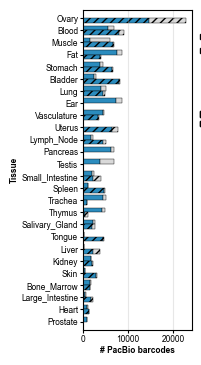

In [10]:
# --- plot: SR <-> PacBio barcode overlap per tissue, split by donor sex ------
# Grouped horizontal bars like the cell-count bar plot (Male above / Female below
# per tissue, Female hatched), each stacked shared (SR ∩ PacBio) + PacBio-only.
from matplotlib.patches import Patch

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6, "figure.titlesize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# tissue order: total PacBio barcodes desc, largest at top
y_order = list(reversed(ov_tissue.index.tolist()))
y = np.arange(len(y_order))

def _pivot(col):
    return (ov_ts.pivot_table(index="tissue", columns="sex", values=col, observed=True)
            .reindex(index=y_order, columns=["Male", "Female"]))

shared, only, total = (_pivot(c) for c in ["n_shared", "pacbio_only", "n_pacbio"])

h = 0.4
SHARED_C, ONLY_C = "#2b8cbe", "#d9d9d9"

fig, axc = plt.subplots(
    1, 1, figsize=(1.4, 0.16 * len(y_order)),
)

# Stacked shared + PacBio-only, Male above / Female below (Female hatched)
for sex, off, hatch in [("Male", h / 2, None), ("Female", -h / 2, "////")]:
    sh = shared[sex].fillna(0).values
    on = only[sex].fillna(0).values
    axc.barh(y + off, sh, height=h, color=SHARED_C, edgecolor="black", linewidth=0.3, hatch=hatch)
    axc.barh(y + off, on, left=sh, height=h, color=ONLY_C, edgecolor="black", linewidth=0.3, hatch=hatch)
axc.set_yticks(y)
axc.set_yticklabels(y_order)
axc.set_ylim(-0.7, len(y_order) - 0.3)
axc.set_xlabel("# PacBio barcodes")
axc.set_ylabel("Tissue")
axc.set_xlim(0, np.nanmax(total.values) * 1.05)
axc.grid(axis="x", alpha=0.3)
axc.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)

# legends to the right of the plot (stacked top-down)
type_handles = [Patch(facecolor=SHARED_C, edgecolor="black", label="Shared\n(SR ∩ PacBio)"),
                Patch(facecolor=ONLY_C, edgecolor="black", label="PacBio only")]
sex_handles = [Patch(facecolor="lightgrey", edgecolor="black", label="Male"),
               Patch(facecolor="lightgrey", edgecolor="black", hatch="////", label="Female")]
leg_type = axc.legend(handles=type_handles, title="Barcodes", frameon=False,
                      bbox_to_anchor=(1.02, 1.0), loc="upper left", alignment="left")
leg_type.get_title().set_fontweight("bold")
axc.add_artist(leg_type)
leg_sex = axc.legend(handles=sex_handles, title="Sex", frameon=False,
                     bbox_to_anchor=(1.02, 0.74), loc="upper left", alignment="left")
leg_sex.get_title().set_fontweight("bold")
axc.add_artist(leg_sex)

# fig.suptitle("Short-read ↔ long-read cell barcode overlap per tissue", y=0.92)
plt.savefig(figpath("02_01_sr_pacbio_barcode_overlap_bysex.pdf"))
plt.show()

## UMIs, genes, pbids, ensemblids & ensemblids_annotatedonly detected per cell across tissues

Five box-plot panels sharing the tissue y-axis — **UMIs per cell** (`total_counts`), **genes detected per cell** (`n_genes_by_counts` on the genes object), **molecules detected per cell** (`n_genes_by_counts` on the pbids object), **transcripts detected per cell** (ensemblids object) and **isoforms detected per cell** (ensemblids_annotatedonly object), all from `sc.pp.calculate_qc_metrics`. Each is **split by donor sex** like the cell-count bar plot (Male above / Female below per tissue row, colored by the same tissue palette, Female hatched). Tissues ordered by total cell count (largest at top; same order as the cell-count bar plot); log x-axes.

All four preprocessed levels are harmonized to an identical cell set in 01_08 (step 6), so the panels are directly comparable per cell. The genes / ensemblids / ensemblids_annotatedonly objects are read one at a time and freed before the next (2–3 GB each) since only the per-cell detected-feature count is needed.

In [11]:
import gc
import random
from matplotlib.patches import Patch

# --- formatting ------------
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6, "figure.titlesize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# per-cell QC on the pbids object (already loaded as `adata`)
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
mol_df = pd.DataFrame({
    "tissue": adata.obs["tissue"].astype(str).values,
    "donor": adata.obs["donor"].astype(str).values,
    "umi": adata.obs["total_counts"].values,          # UMIs per cell
    "n_mol": adata.obs["n_genes_by_counts"].values,   # molecules detected per cell
})
mol_df["sex"] = mol_df["donor"].map(donor_sex)


# The other three levels (genes / ensemblids / ensemblids_annotatedonly) each need their own h5ad.
# They are 2-3 GB apiece and only the per-cell detected-feature count is needed, so
# load one at a time, keep the small obs-level frame, and free the object before the
# next read (all four preprocessed objects share an identical cell set — 01_08 step 6
# harmonizes them — so the per-object frames line up tissue-for-tissue).
def per_cell_detected(level, colname):
    """n_genes_by_counts (= features detected per cell) on one preprocessed level."""
    a = sc.read_h5ad(
        f"./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_{level}"
        "_bc_anndata_preprocessed.h5ad"
    )
    sc.pp.calculate_qc_metrics(a, percent_top=None, log1p=False, inplace=True)
    df = pd.DataFrame({
        "tissue": a.obs["tissue"].astype(str).values,
        "donor": a.obs["donor"].astype(str).values,
        colname: a.obs["n_genes_by_counts"].values,
    })
    df["sex"] = df["donor"].map(donor_sex)
    print(f"{level}: {a.shape[0]:,} cells x {a.shape[1]:,} features; "
          f"median {colname} = {np.median(df[colname]):,.0f}")
    del a
    gc.collect()
    return df


gene_df = per_cell_detected("genes", "n_gene")            # genes detected per cell
tx_df = per_cell_detected("ensemblids", "n_tx")          # transcripts detected per cell
iso_df = per_cell_detected("ensemblids_annotatedonly", "n_iso")           # isoforms detected per cell

genes: 203,311 cells x 49,124 features; median n_gene = 942
ensemblids: 203,311 cells x 489,842 features; median n_tx = 1,054
ensemblids_annotatedonly: 203,311 cells x 145,051 features; median n_iso = 959


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


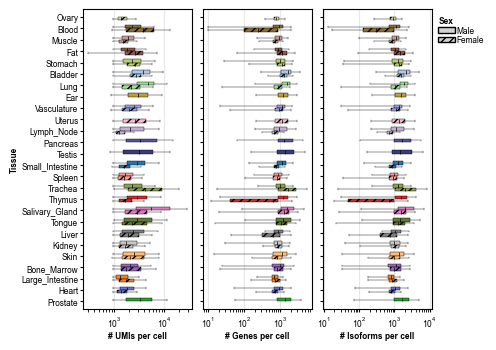

In [12]:
# Box plots: UMIs / genes / pbids / ensemblids / ensemblids_annotatedonly detected per cell across
# tissues, split by donor sex. Five panels sharing the tissue y-axis. Two boxes per tissue
# row (Male above, Female below), colored by tissue (same palette as the cell-count bar
# plot); Female boxes hatched.
#   - UMIs per cell         = total_counts on the pbids object
#   - genes per cell        = n_genes_by_counts on the genes object
#   - molecules per cell    = n_genes_by_counts on the pbids object (features detected)
#   - transcripts per cell  = n_genes_by_counts on the ensemblids object
#   - isoforms per cell     = n_genes_by_counts on the ensemblids_annotatedonly object
# Each level lives in its own h5ad (loaded in the cell above); all four preprocessed
# objects share an identical cell set, so the panels are directly comparable.

# same tissue palette as the cell-count bar plot (colors keyed by total-cell rank)
tissue_tot_cells = counts.groupby("tissue", observed=True)["n_cells"].sum().sort_values(ascending=False)
palette40 = sns.color_palette("tab20", 16) + sns.color_palette("tab20b", 10)
random.Random(1).shuffle(palette40)
tissue_palette = dict(zip(list(tissue_tot_cells.index), palette40[:len(tissue_tot_cells)]))

# tissue order: total cell counts descending, largest at top (same order as the cell-count bar plot)
y_labels = [t for t in reversed(tissue_tot_cells.index.tolist()) if t in set(mol_df["tissue"])]
ypos = {t: i for i, t in enumerate(y_labels)}

h = 0.3

def draw_box_panel(ax, df, valcol, xlabel):
    for t in y_labels:
        for sex, off, hatch in [("Male", h / 2, None), ("Female", -h / 2, "////")]:
            vals = df.loc[(df["tissue"] == t) & (df["sex"] == sex), valcol].values
            if len(vals) == 0:
                continue
            bp = ax.boxplot(
                vals, positions=[ypos[t] + off], widths=h, vert=False,
                patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=0.5),
                boxprops=dict(linewidth=0.3, edgecolor="black"),
                whiskerprops=dict(linewidth=0.3), capprops=dict(linewidth=0.3),
            )
            for box in bp["boxes"]:
                box.set_facecolor(tissue_palette[t])
                if hatch:
                    box.set_hatch(hatch)
    ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)

# (dataframe, column, x label) per panel, left -> right
panels = [
    (mol_df,  "umi",    "# UMIs per cell"),
    (gene_df, "n_gene", "# Genes per cell"),
    (mol_df,  "n_mol",  "# Isoforms per cell"),
    # (tx_df,   "n_tx",   "# Transcripts per cell"),
    # (iso_df,  "n_iso",  "# Isoforms per cell"),
]

fig, axes = plt.subplots(1, len(panels), figsize=(1.5 * len(panels), 0.15 * len(y_labels)),
                         sharey=True)
for ax, (df, valcol, xlabel) in zip(axes, panels):
    draw_box_panel(ax, df, valcol, xlabel)

# shared tissue y-axis (labels on leftmost only; sharey hides the others)
axes[0].set_yticks(range(len(y_labels)))
axes[0].set_yticklabels(y_labels)
axes[0].set_ylabel("Tissue")
axes[0].set_ylim(-0.7, len(y_labels) - 0.3)

# legend maps hatch -> sex (color encodes tissue), on the rightmost panel
sex_handles = [
    Patch(facecolor="lightgrey", edgecolor="black", label="Male"),
    Patch(facecolor="lightgrey", edgecolor="black", hatch="////", label="Female"),
]
leg = axes[-1].legend(handles=sex_handles, title="Sex", frameon=False,
                      bbox_to_anchor=(1.0, 1.0), loc="upper left", alignment  = "left")
leg.get_title().set_fontweight("bold")

plt.subplots_adjust(wspace = 0.1)
plt.savefig(figpath("02_01_pacbio_umi_genes_molecules_per_cell_box_bysex.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()